# Startup Viability Prediction with Lebanese Risk Adjustment
### iPark — AUB Innovation Park Research Project
**Data:** Crunchbase Startups (n=923) | **Method:** ML Baseline + Lebanese Risk Scoring Layer | **Framework:** iPark Failure Taxonomy 

---
## Project Architecture
```
Load data + raw feature overview
    ↓
Map to iPark — connect to known failure reasons
    ↓
EDA — understand data within a business framework (iPark's Startup Failure framework)
    ↓
Feature engineering — build meaningful variables
    ↓
ML model — train and evaluate
    ↓
Feature importance — what the model actually learned
    ↓
Lebanese Risk Layer — rule-based penalty per sector
    ↓
AdjustedScore = BaselineML − LebaneseRiskPenalty
    ↓
Recommendations Dashboard
```


## 0. Setup

In [5]:
!pip install xgboost scikit-learn -q

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report)

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

# Color palette
C_SUCCESS = '#2ecc71'
C_FAIL    = '#e74c3c'
C_BLUE    = '#2980b9'
C_DARK    = '#2c3e50'
C_ORANGE  = '#e67e22'
C_PURPLE  = '#8e44ad'

print("All imports ready")

All imports ready


## 1. Data Loading & iPark's Framework

In [6]:
import pandas as pd

df = pd.read_csv("startup data.csv")   

df['target'] = (df['status'] == 'acquired').astype(int)
print(f"Shape: {df.shape}")
print(f"Acquired: {df['target'].sum()} | Closed: {(df['target']==0).sum()}")
df.head(3)

Shape: (923, 50)
Acquired: 597 | Closed: 326


,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status,target
0,1005,CA,42.358880,-71.056820,92101,c:6669,San Diego,NaN,Bandsintown,1,...,0,1,0,0,0,0,1.00,0,acquired,1
1,204,CA,37.238916,-121.973718,95032,c:16283,Los Gatos,NaN,TriCipher,1,...,1,0,0,1,1,1,4.75,1,acquired,1
2,1001,CA,32.901049,-117.192656,92121,c:65620,San Diego,San Diego CA 92121,Plixi,1,...,0,0,1,0,0,0,4.00,1,acquired,1


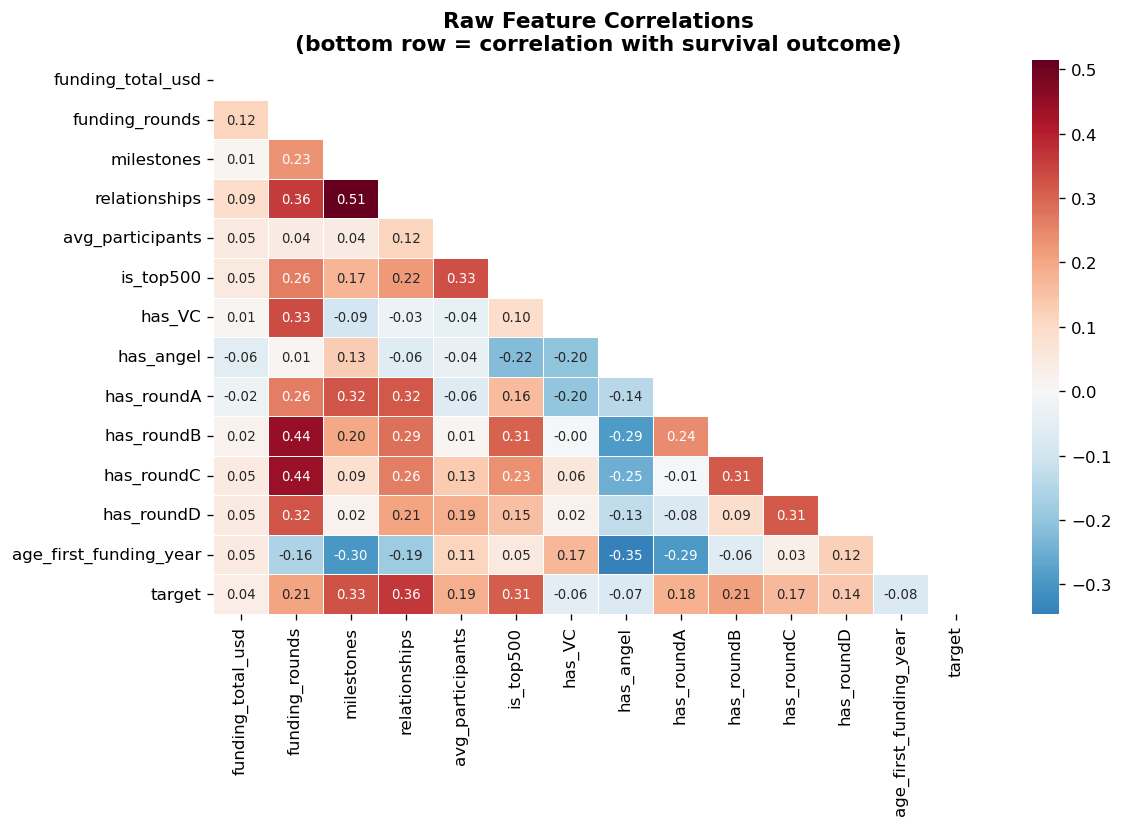

Features ranked by correlation with survival:
relationships             0.3604
milestones                0.3283
is_top500                 0.3107
has_roundB                0.2083
funding_rounds            0.2060
avg_participants          0.1860
has_roundA                0.1843
has_roundC                0.1659
has_roundD                0.1399
age_first_funding_year    0.0756
has_angel                 0.0728
has_VC                    0.0565
funding_total_usd         0.0402


In [7]:
fig, ax = plt.subplots(figsize=(10, 7))

raw_cols = [
    'funding_total_usd', 'funding_rounds', 'milestones',
    'relationships', 'avg_participants', 'is_top500',
    'has_VC', 'has_angel', 'has_roundA', 'has_roundB',
    'has_roundC', 'has_roundD', 'age_first_funding_year',
]

corr = df[raw_cols + ['target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_title("Raw Feature Correlations\n(bottom row = correlation with survival outcome)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the target row specifically so it's readable
tc = corr['target'].drop('target').abs().sort_values(ascending=False)
print("Features ranked by correlation with survival:")
print(tc.round(4).to_string())


## iPark's Take on Why startups fail

This slide ranks the top 12 reasons startups fail globally, based on CB Insights data gathered by a research done by iPark.
We use this as our reference framework and cross-check it against what the Crunchbase 
data actually measures.


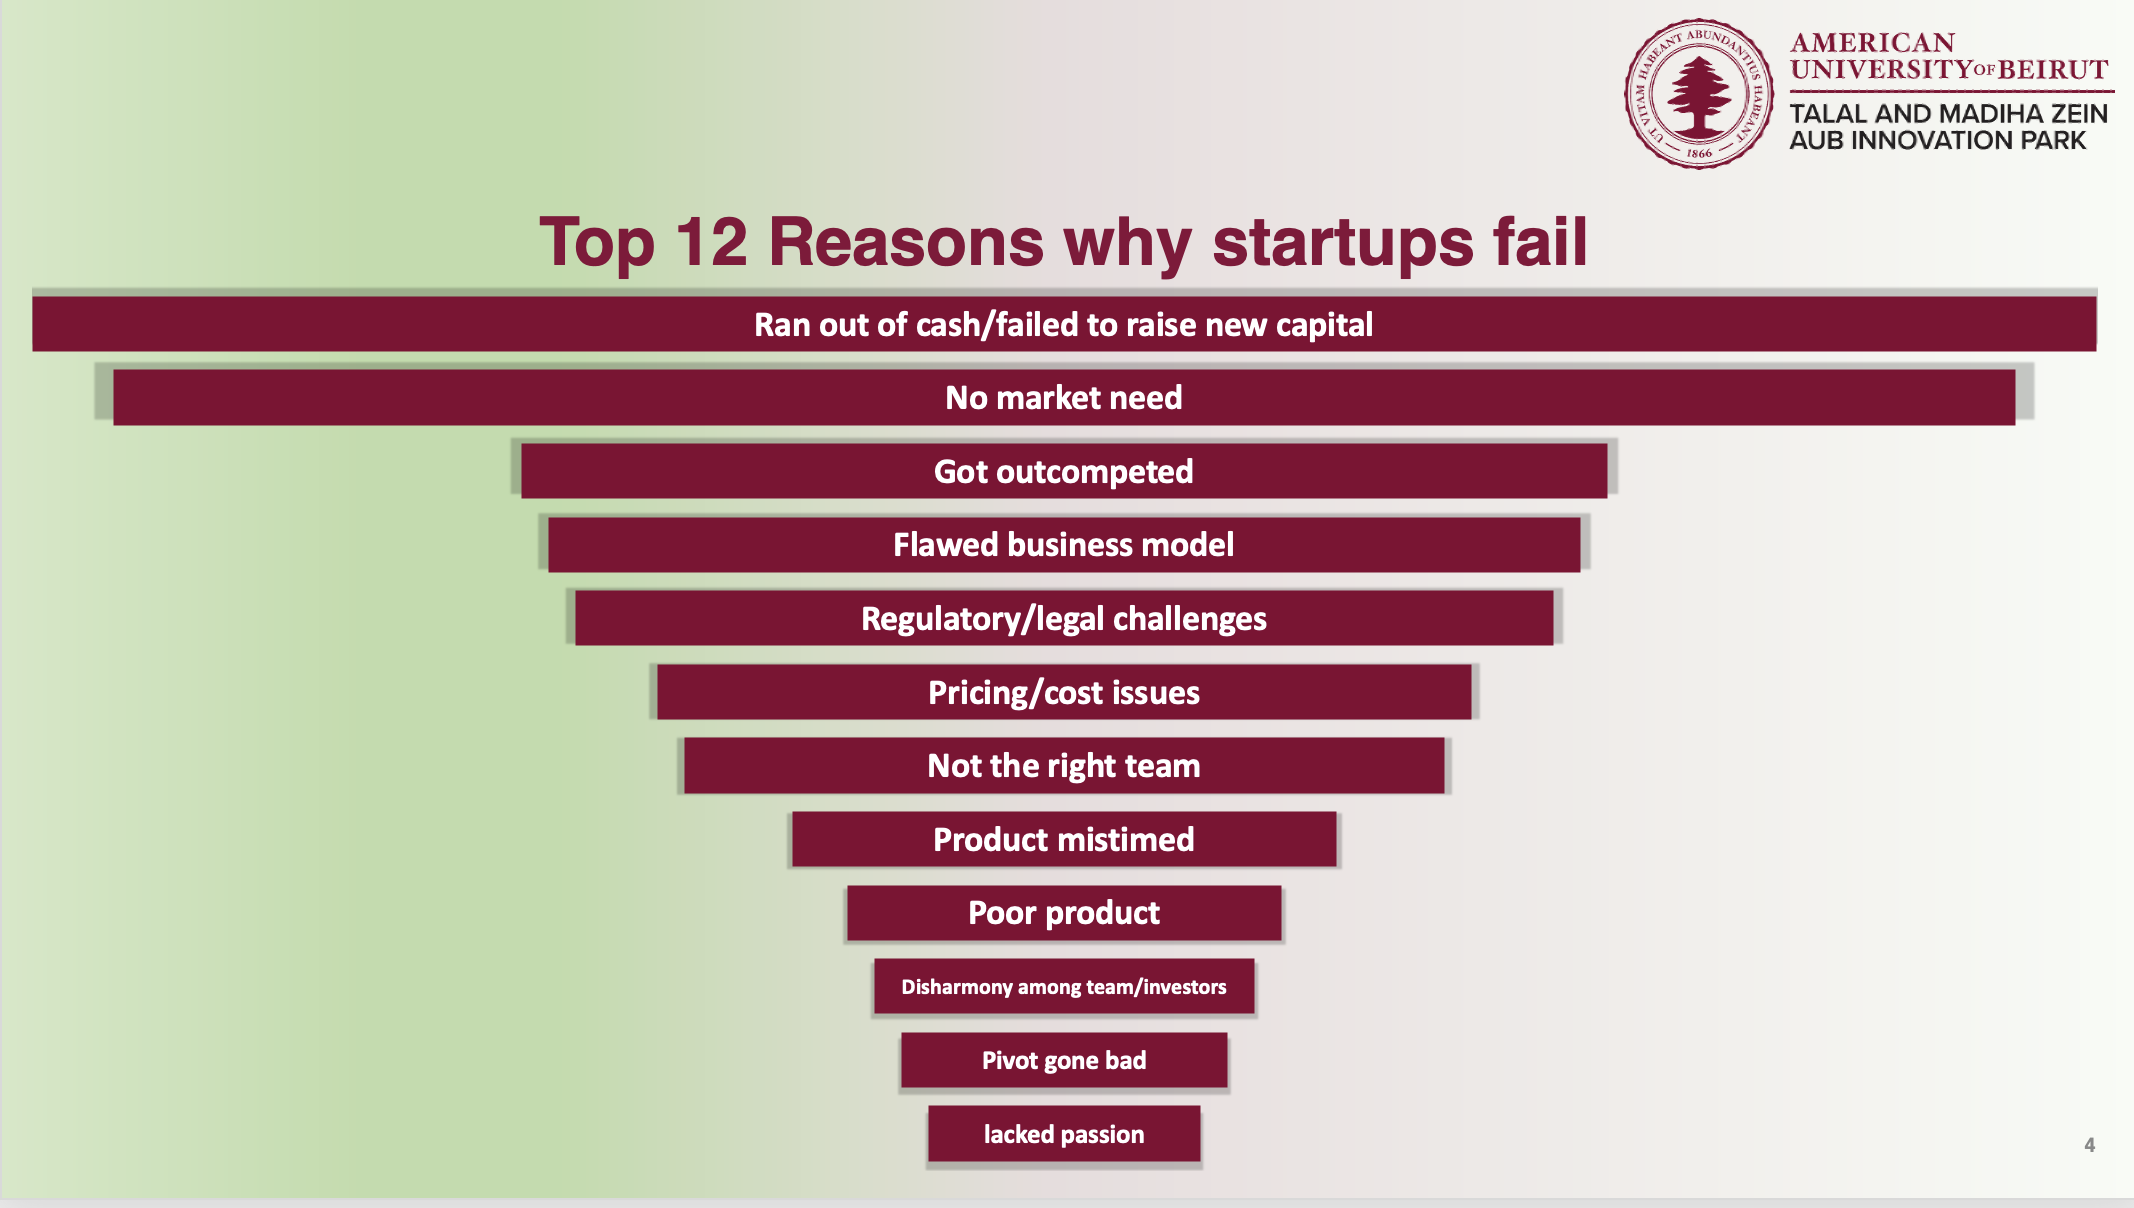

In [8]:
from IPython.display import Image, display

display(Image('/Users/joulnarabouchakra/Desktop/data startup success/whystartupsfail - ss1.png'))

### Data vs iPark Framework — What Aligns 

Correlation analysis on 923 Crunchbase startups identifies **5 statistically 
significant predictors** of startup survival, similar to iPark's findings:

| Rank | Feature | Correlation | iPark Failure Reason |
|------|---------|-------------|----------------------|
| 1 | relationships | 0.36 | ⑦ Not the right team |
| 2 | milestones | 0.33 | ② No market need |
| 3 | is_top500 | 0.31 | ③ Got outcompeted |
| 4 | has_roundB | 0.21 | ④ Flawed business model |
| 5 | funding_rounds | 0.21 | ① Ran out of cash |

> **Key finding:** Total funding amount (corr=0.04) barely predicts survival,
> but funding rounds (corr=0.21) does. This supports iPark's ① — startups don't 
> fail because the first cheque was too small. They fail because they couldn't prove enough traction to raise the next one.

## 2. Exploratory Data Analysis
### 2.1 Class balance & overall picture - Overview


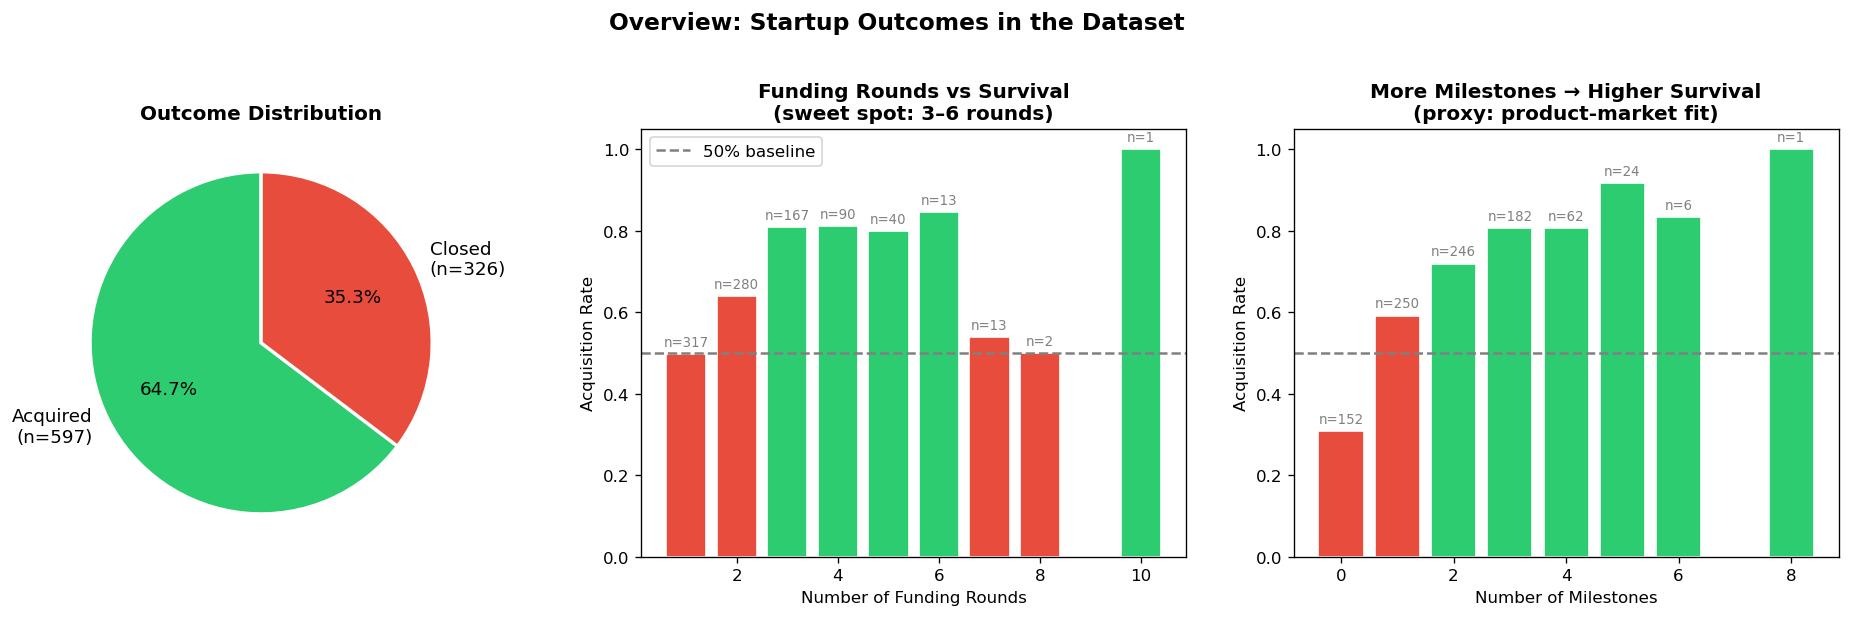

Key insight: 0 milestones → only 31% survive. 5 milestones → 92% survive.
Key insight: 1 round → 50% survival. Sweet spot is 3-56 rounds (80%+). Beyond 7 rounds survival drops, likely signals inability to exit.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Overview: Startup Outcomes in the Dataset", fontsize=14, fontweight='bold', y=1.02)

# Class balance
sizes  = [df['target'].sum(), (df['target']==0).sum()]
labels = [f'Acquired\n(n={sizes[0]})', f'Closed\n(n={sizes[1]})']
axes[0].pie(sizes, labels=labels, colors=[C_SUCCESS, C_FAIL],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize':11}, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title("Outcome Distribution", fontweight='bold')

# Funding rounds distribution
fr = df.groupby('funding_rounds')['target'].agg(['mean','count']).reset_index()
ax2 = axes[1]
bars = ax2.bar(fr['funding_rounds'], fr['mean'],
               color=[C_SUCCESS if v>0.65 else C_FAIL for v in fr['mean']], edgecolor='white')
ax2.axhline(0.5, color='gray', ls='--', lw=1.5, label='50% baseline')
ax2.set_xlabel("Number of Funding Rounds"); ax2.set_ylabel("Acquisition Rate")
ax2.set_title("Funding Rounds vs Survival\n(sweet spot: 3–6 rounds)", fontweight='bold')
ax2.legend()
for bar, row in zip(bars, fr.itertuples()):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f'n={row.count}', ha='center', fontsize=8, color='gray')

# Milestones distribution
ms = df.groupby('milestones')['target'].agg(['mean','count']).reset_index()
bars2 = axes[2].bar(ms['milestones'], ms['mean'],
                    color=[C_SUCCESS if v>0.65 else C_FAIL for v in ms['mean']], edgecolor='white')
axes[2].axhline(0.5, color='gray', ls='--', lw=1.5)
axes[2].set_xlabel("Number of Milestones"); axes[2].set_ylabel("Acquisition Rate")
axes[2].set_title("More Milestones → Higher Survival\n(proxy: product-market fit)", fontweight='bold')
for bar, row in zip(bars2, ms.itertuples()):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'n={row.count}', ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()
print("Key insight: 0 milestones → only 31% survive. 5 milestones → 92% survive.")
print("Key insight: 1 round → 50% survival. Sweet spot is 3-56 rounds (80%+). Beyond 7 rounds survival drops, likely signals inability to exit.")

### 2.2 The 5 Measurable Failure Reasons


### 2.21 Failure Reason ⑦: Team — Network Quality as Survival Predictor
Strong teams attract investors, advisors, and partners. Weak teams stay isolated.
In structured data, the closest proxy available in our data shows up as `relationships` in reference to the ecosystem connections a startup has built.

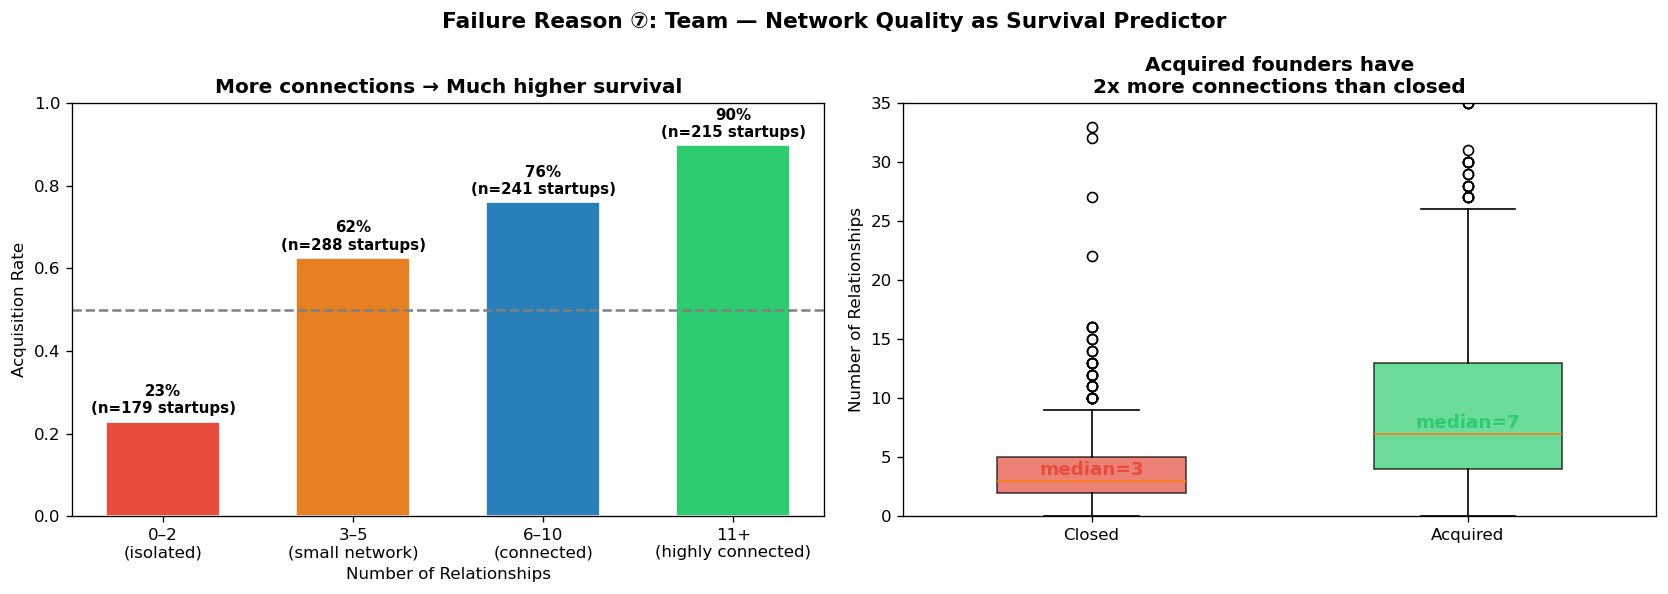

Graph 1-2: from left to right
Graph 1: Relationships is the strongest predictor in the dataset (corr=0.36). Isolated founders (0–2 connections) survive at only 23%. While highly connected founders (11+) survive at 90%.
Graph 2: Acquired founders have 2x more connections than closed founders (median 7 vs 3).
Conclusion: Team quality in data = network depth. You cannot build a startup alone.


In [24]:
df['rel_group'] = pd.cut(df['relationships'],
                          bins=[-1, 2, 5, 10, 100],
                          labels=['0–2\n(isolated)', '3–5\n(small network)',
                                  '6–10\n(connected)', '11+\n(highly connected)'])

rel = df.groupby('rel_group', observed=True)['target'].agg(['mean','count']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Failure Reason ⑦: Team — Network Quality as Survival Predictor",
             fontsize=13, fontweight='bold')

bars = axes[0].bar(rel['rel_group'], rel['mean'],
                   color=[C_FAIL, C_ORANGE, C_BLUE, C_SUCCESS], edgecolor='white', width=0.6)
axes[0].axhline(0.5, color='gray', ls='--', lw=1.5)
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("Number of Relationships")
axes[0].set_ylabel("Acquisition Rate")
axes[0].set_title("More connections → Much higher survival", fontweight='bold')
for bar, row in zip(bars, rel.itertuples()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{row.mean:.0%}\n(n={row.count} startups)', ha='center', fontsize=9, fontweight='bold')

data_acquired = df[df['target']==1]['relationships']
data_closed   = df[df['target']==0]['relationships']

bp = axes[1].boxplot([data_closed, data_acquired],
                     patch_artist=True,
                     labels=['Closed', 'Acquired'],
                     widths=0.5)

bp['boxes'][0].set_facecolor(C_FAIL)
bp['boxes'][1].set_facecolor(C_SUCCESS)
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_alpha(0.7)

axes[1].set_ylabel("Number of Relationships")
axes[1].set_title("Acquired founders have\n2x more connections than closed", fontweight='bold')
axes[1].text(1, data_closed.median()+0.5,
             f'median={data_closed.median():.0f}',
             ha='center', fontsize=11, fontweight='bold', color=C_FAIL)
axes[1].text(2, data_acquired.median()+0.5,
             f'median={data_acquired.median():.0f}',
             ha='center', fontsize=11, fontweight='bold', color=C_SUCCESS)
axes[1].set_ylim(0, 35)
plt.tight_layout()
plt.show()

print("Graph 1-2: from left to right")

print("Graph 1: Relationships is the strongest predictor in the dataset (corr=0.36). Isolated founders (0–2 connections) survive at only 23%. While highly connected founders (11+) survive at 90%.")
print("Graph 2: Acquired founders have 2x more connections than closed founders (median 7 vs 3).")
print("Conclusion: Team quality in data = network depth. You cannot build a startup alone.")

### 2.22 Failure Reason ②: No market need

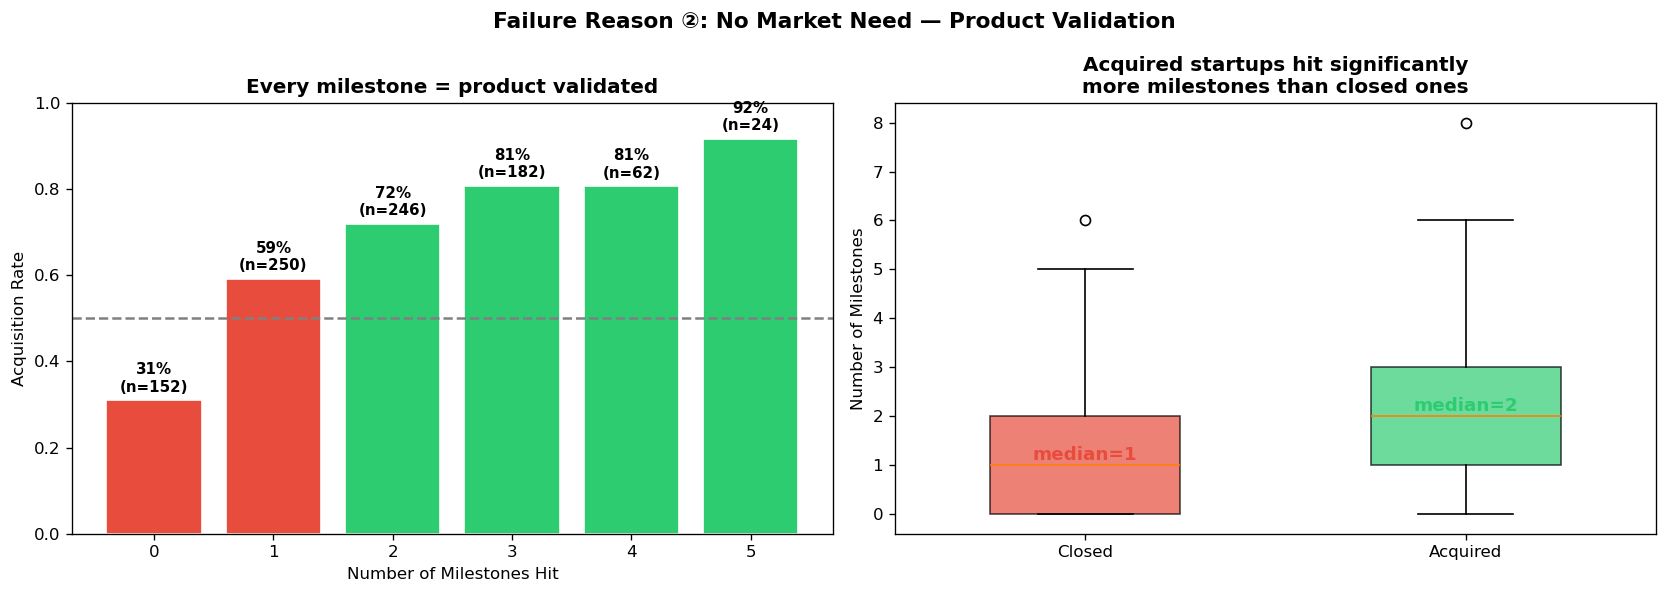

Graph 1-2, left to right
Graph 1: 0 milestones → only 31% survive. These startups never validated anything. Each milestone adds ~15-20% survival probability.
Graph 2: Milestones are a proxy for product-market fit — shipping, testing, proving.
Conclusion: Hani's ② confirmed — founders who never validate their product almost always fail.


In [45]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Failure Reason ②: No Market Need — Product Validation",
             fontsize=13, fontweight='bold')

# Panel 1: Milestone count vs survival rate
ms = df.groupby('milestones')['target'].agg(['mean','count']).reset_index()
ms = ms[ms['count'] >= 10]  # remove unreliable small samples
bars = axes[0].bar(ms['milestones'], ms['mean'],
                   color=[C_SUCCESS if v > 0.65 else C_FAIL for v in ms['mean']],
                   edgecolor='white')
axes[0].axhline(0.5, color='gray', ls='--', lw=1.5)
axes[0].set_xlabel("Number of Milestones Hit")
axes[0].set_ylabel("Acquisition Rate")
axes[0].set_ylim(0, 1)
axes[0].set_title("Every milestone = product validated",
                  fontweight='bold')
for bar, row in zip(bars, ms.itertuples()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{row.mean:.0%}\n(n={row.count})',
                 ha='center', fontsize=9, fontweight='bold')

# Panel 2: Milestone distribution boxplot
bp = axes[1].boxplot(
    [df[df['target']==0]['milestones'],
     df[df['target']==1]['milestones']],
    patch_artist=True,
    labels=['Closed', 'Acquired'],
    widths=0.5
)
bp['boxes'][0].set_facecolor(C_FAIL);    bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(C_SUCCESS); bp['boxes'][1].set_alpha(0.7)
axes[1].set_ylabel("Number of Milestones")
axes[1].set_title("Acquired startups hit significantly\nmore milestones than closed ones",
                  fontweight='bold')

med0 = df[df['target']==0]['milestones'].median()
med1 = df[df['target']==1]['milestones'].median()
axes[1].text(1, med0+0.1, f'median={med0:.0f}', ha='center',
             fontsize=11, fontweight='bold', color=C_FAIL)
axes[1].text(2, med1+0.1, f'median={med1:.0f}', ha='center',
             fontsize=11, fontweight='bold', color=C_SUCCESS)

plt.tight_layout()
plt.show()
print("Graph 1-2, left to right")
print("Graph 1: 0 milestones → only 31% survive. These startups never validated anything. Each milestone adds ~15-20% survival probability.")
print("Graph 2: Milestones are a proxy for product-market fit — shipping, testing, proving.")
print("Conclusion: Hani's ② confirmed — founders who never validate their product almost always fail.")

### 2.23 Failure Reason ③ & ⑧: Competition moat

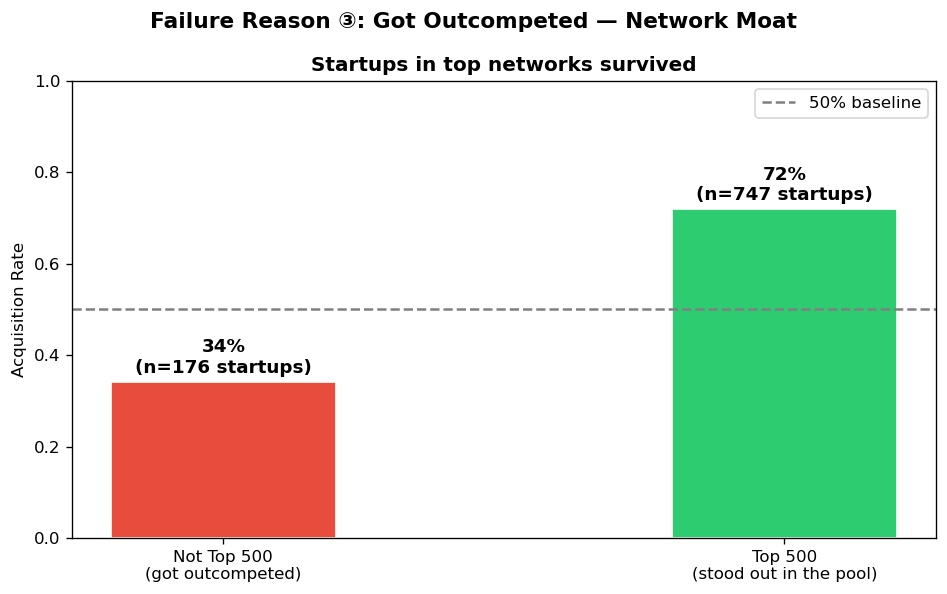

Conclusion: Being in a top means you stood out. Being outside means a better-positioned competitor took the market before you could.


In [42]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Failure Reason ③: Got Outcompeted — Network Moat",
             fontsize=13, fontweight='bold')

top500 = df.groupby('is_top500')['target'].agg(['mean','count']).reset_index()
bars = ax.bar(['Not Top 500\n(got outcompeted)', 'Top 500\n(stood out in the pool)'],
              top500['mean'], color=[C_FAIL, C_SUCCESS], edgecolor='white', width=0.4)
ax.axhline(0.5, color='gray', ls='--', lw=1.5, label='50% baseline')
ax.set_ylabel("Acquisition Rate")
ax.set_ylim(0, 1)
ax.set_title("Startups in top networks survived",
             fontweight='bold')
ax.legend()
for bar, row in zip(bars, top500.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{row.mean:.0%}\n(n={row.count} startups)',
            ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("Conclusion: Being in a top means you stood out. " 
    "Being outside means a better-positioned competitor took the market before you could.")

### 2.24 Failure Reason ④: Flawed Business Model — Capital vs Execution"

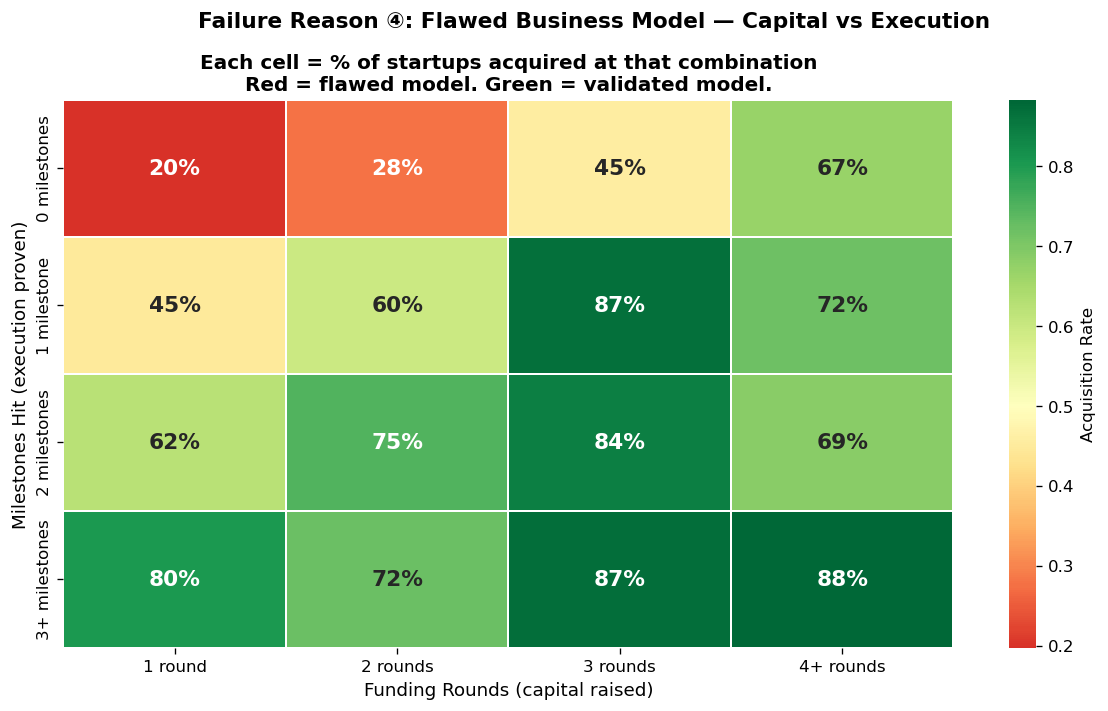

Finding 1: 0 milestones + 1 round → only 20% acquired — raised money, proved nothing.
Finding 2: 3+ milestones + 4+ rounds → 88% acquired — capital and execution aligned.
Finding 3: Neither rounds nor milestones alone is enough — the highest survival consistently appears when both are high simultaneously.
Conclusion: A flawed business model = imbalance between capital raised and execution proven.


In [51]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Failure Reason ④: Flawed Business Model — Capital vs Execution",
             fontsize=13, fontweight='bold')

# Bin funding rounds and milestones into meaningful groups
df['_fund_group'] = pd.cut(df['funding_rounds'],
                            bins=[0, 1, 2, 3, 10],
                            labels=['1 round', '2 rounds', '3 rounds', '4+ rounds'])
df['_mile_group'] = pd.cut(df['milestones'],
                            bins=[-1, 0, 1, 2, 10],
                            labels=['0 milestones', '1 milestone', '2 milestones', '3+ milestones'])

pivot = df.pivot_table(
    values='target',
    index='_mile_group',
    columns='_fund_group',
    aggfunc='mean'
)

sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn',
            center=0.5, linewidths=1, ax=ax,
            annot_kws={'size': 13, 'fontweight': 'bold'},
            cbar_kws={'label': 'Acquisition Rate'})

ax.set_xlabel("Funding Rounds (capital raised)", fontsize=11)
ax.set_ylabel("Milestones Hit (execution proven)", fontsize=11)
ax.set_title("Each cell = % of startups acquired at that combination\n"
             "Red = flawed model. Green = validated model.",
             fontweight='bold')

plt.tight_layout()
plt.show()

print("Finding 1: 0 milestones + 1 round → only 20% acquired — raised money, proved nothing.")
print("Finding 2: 3+ milestones + 4+ rounds → 88% acquired — capital and execution aligned.")
print("Finding 3: Neither rounds nor milestones alone is enough — the highest survival consistently appears when both are high simultaneously.")
print("Conclusion: A flawed business model = imbalance between capital raised and execution proven.")


### 2.25 Failure Reason ①: Ran out of cash / Failed to raise capital"
How does the top feature on iPark's list look in our data?

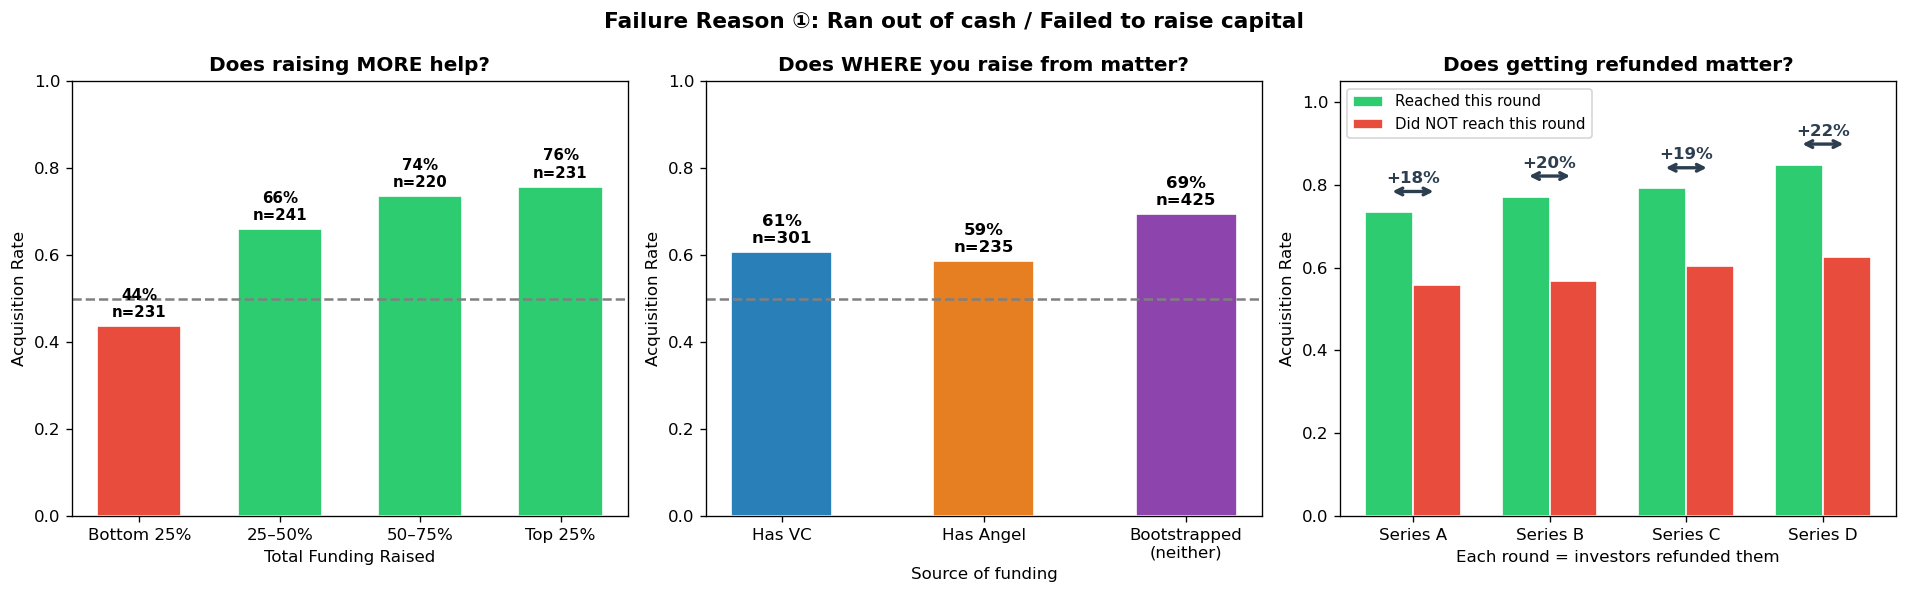

Graph from 1 to 3, left to right
Finding 1 - Graph 1:  Underfunding kills, bottom 25% survive at only 44%. But beyond that, more money adds little
Finding 2 - Graph 2: Source of capital (VC/Angel/Bootstrap) produces nearly identical survival rates.
Finding 3 - Graph 3: What matters is how many times investors kept believing. Each Series round = more traction proven. Startups that couldn't raise again ran out of cash and closed.
Conclusion: Startups don't fail because the cheque was too small, they fail because they couldn't prove enough traction to get the next one.


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Failure Reason ①: Ran out of cash / Failed to raise capital",
             fontsize=13, fontweight='bold')

# Panel 1: Funding amount quartiles vs survival
df['funding_quartile'] = pd.qcut(df['funding_total_usd'], 4,
                                  labels=['Bottom 25%', '25–50%', '50–75%', 'Top 25%'])
fq = df.groupby('funding_quartile', observed=True)['target'].agg(['mean','count']).reset_index()
bars0 = axes[0].bar(fq['funding_quartile'], fq['mean'],
                    color=[C_SUCCESS if v > 0.65 else C_FAIL for v in fq['mean']],
                    edgecolor='white', width=0.6)
axes[0].axhline(0.5, color='gray', ls='--', lw=1.5)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Acquisition Rate")
axes[0].set_xlabel("Total Funding Raised")
axes[0].set_title("Does raising MORE help?",
                  fontweight='bold')
for bar, row in zip(bars0, fq.itertuples()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{row.mean:.0%}\nn={row.count}', ha='center', fontsize=9, fontweight='bold')

# Panel 2: VC vs Angel vs Bootstrap
categories = ['Has VC', 'Has Angel', 'Bootstrapped\n(neither)']
rates  = [df[df['has_VC']==1]['target'].mean(),
          df[df['has_angel']==1]['target'].mean(),
          df[(df['has_VC']==0)&(df['has_angel']==0)]['target'].mean()]
counts = [df['has_VC'].sum(), df['has_angel'].sum(),
          ((df['has_VC']==0)&(df['has_angel']==0)).sum()]
bars1  = axes[1].bar(categories, rates,
                     color=[C_BLUE, C_ORANGE, C_PURPLE], edgecolor='white', width=0.5)
axes[1].axhline(0.5, color='gray', ls='--', lw=1.5)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Acquisition Rate")
axes[1].set_xlabel("Source of funding")
axes[1].set_title("Does WHERE you raise from matter?",
                  fontweight='bold')
for bar, rate, n in zip(bars1, rates, counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{rate:.0%}\nn={n}', ha='center', fontsize=10, fontweight='bold')

# Panel 3: Survival gap at each series round
round_cols   = ['has_roundA','has_roundB','has_roundC','has_roundD']
round_labels = ['Series A',  'Series B',  'Series C',  'Series D']
has_rates    = [df[df[c]==1]['target'].mean() for c in round_cols]
no_rates     = [df[df[c]==0]['target'].mean() for c in round_cols]
gaps         = [h - n for h, n in zip(has_rates, no_rates)]

x = np.arange(len(round_labels)); w = 0.35
axes[2].bar(x - w/2, has_rates, w, label='Reached this round',
            color=C_SUCCESS, edgecolor='white')
axes[2].bar(x + w/2, no_rates,  w, label='Did NOT reach this round',
            color=C_FAIL, edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(round_labels)
axes[2].set_ylim(0, 1.05)
axes[2].set_ylabel("Acquisition Rate")
axes[2].set_xlabel("Each round = investors refunded them")
axes[2].set_title("Does getting refunded matter?",
                  fontweight='bold')
axes[2].legend(fontsize=9)

# Show the gap clearly on top of each pair
for i, gap in enumerate(gaps):
    axes[2].annotate('', xy=(i + w/2, max(has_rates[i], no_rates[i]) + 0.05),
                     xytext=(i - w/2, max(has_rates[i], no_rates[i]) + 0.05),
                     arrowprops=dict(arrowstyle='<->', color=C_DARK, lw=2))
    axes[2].text(i, max(has_rates[i], no_rates[i]) + 0.07,
                 f'+{gap:.0%}', ha='center', fontsize=10,
                 fontweight='bold', color=C_DARK)

plt.tight_layout()
plt.show()
print("Graph from 1 to 3, left to right")

print("Finding 1 - Graph 1:  Underfunding kills, bottom 25% survive at only 44%. But beyond that, more money adds little")
print("Finding 2 - Graph 2: Source of capital (VC/Angel/Bootstrap) produces nearly identical survival rates.")
print("Finding 3 - Graph 3: What matters is how many times investors kept believing. Each Series round = more traction proven. Startups that couldn't raise again ran out of cash and closed.")
print("Conclusion: Startups don't fail because the cheque was too small, they fail because they couldn't prove enough traction to get the next one.")

## 4. Feature Engineering
We know from the EDA which signals actually matter. Now we turn them into clean, model-ready variables, each one representing a real failure reason iPark identified, not just a number in a spreadsheet.

In [53]:
# Each feature maps to one of iPark's 5 confirmed failure reasons

# ── ① Ran out of cash ─────────────────────────────────────────────────
# funding_rounds, has_VC, has_angel, has_roundA-D already exist in raw data

# ── ② No market need ──────────────────────────────────────────────────
# milestones already exists in raw data

# ── ③ Got outcompeted ─────────────────────────────────────────────────
# is_top500 already exists in raw data

# ── ④ Flawed business model ───────────────────────────────────────────
# reached_series_b: binary flag — did the startup prove its model scales?
df['reached_series_b'] = ((df['has_roundB']==1) | (df['has_roundC']==1)).astype(int)

# ── ⑦ Not the right team ──────────────────────────────────────────────
# relationships already exists in raw data
# rel_bucket: used for EDA visualisation only — not passed to model
df['rel_bucket'] = pd.cut(df['relationships'],
                           bins=[-1, 2, 5, 10, 100],
                           labels=['0–2', '3–5', '6–10', '11+'])

# ── Features passed to ML model ───────────────────────────────────────
FEATURES = [
    # ① Ran out of cash
    'funding_rounds',
    'has_VC', 'has_angel',
    'has_roundA', 'has_roundB', 'has_roundC', 'has_roundD',
    # ② No market need
    'milestones',
    # ③ Got outcompeted
    'is_top500',
    # ④ Flawed business model
    'reached_series_b',
    # ⑦ Not the right team
    'relationships',
    # Supporting — shown in correlation heatmap
    'age_first_funding_year',
    'age_last_funding_year',
]

print(f"Total features: {len(FEATURES)}")
print()
print("Feature → iPark Failure Reason mapping:")
mapping = {
    'funding_rounds / has_roundA-D / has_VC / has_angel': '① Ran out of cash',
    'milestones':                                          '② No market need',
    'is_top500':                                           '③ Got outcompeted',
    'reached_series_b':                                    '④ Flawed business model',
    'relationships':                                       '⑦ Not the right team',
    'age_first/last_funding_year':                         'Supporting context',
}
for feat, reason in mapping.items():
    print(f"  {feat:45s} → {reason}")

Total features: 13

Feature → iPark Failure Reason mapping:
  funding_rounds / has_roundA-D / has_VC / has_angel → ① Ran out of cash
  milestones                                    → ② No market need
  is_top500                                     → ③ Got outcompeted
  reached_series_b                              → ④ Flawed business model
  relationships                                 → ⑦ Not the right team
  age_first/last_funding_year                   → Supporting context


## 5. Baseline ML Model

We train 4 classifiers, from simple to complex, to predict startup survival (acquired vs closed).

- **Logistic Regression** — the baseline. If complex models can't beat it, something is wrong.
- **Random Forest** — captures non-linear relationships between features. Works well on tabular data.
- **Gradient Boosting** — builds trees sequentially, each correcting the previous. Generally more accurate.
- **XGBoost** — optimized gradient boosting. Industry standard for tabular ML problems.

If all four agree on which features matter most, that's strong evidence the finding is real, not model-specific.  
The feature importance from the best model becomes our bridge back to Hani's failure reasons.


In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

X = df[FEATURES].copy()
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test  positive rate: {y_test.mean():.3f}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED, C=1.0),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8, random_state=SEED, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=SEED),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=SEED, eval_metric='logloss', verbosity=0),
}

results = {}
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

print("\nTraining models...")
for name, clf in models.items():
    Xtr = X_train_sc if name == 'Logistic Regression' else X_train
    Xte = X_test_sc  if name == 'Logistic Regression' else X_test

    r = cross_validate(clf, Xtr, y_train, cv=cv,
                       scoring=['accuracy','f1','roc_auc'], n_jobs=-1)
    clf.fit(Xtr, y_train)
    yp  = clf.predict(Xte)
    ypr = clf.predict_proba(Xte)[:,1]
    results[name] = {
        'clf': clf,
        'cv_acc': r['test_accuracy'].mean(), 'cv_acc_std': r['test_accuracy'].std(),
        'cv_f1':  r['test_f1'].mean(),
        'cv_auc': r['test_roc_auc'].mean(),
        'test_acc': accuracy_score(y_test, yp),
        'test_f1':  f1_score(y_test, yp),
        'test_auc': roc_auc_score(y_test, ypr),
        'yp': yp, 'ypr': ypr,
        'Xte': Xte,
    }
    print(f"  {name:25s}  CV Acc={r['test_accuracy'].mean():.4f}  "
          f"F1={r['test_f1'].mean():.4f}  AUC={r['test_roc_auc'].mean():.4f}")

Train: 738  Test: 185
Train positive rate: 0.646
Test  positive rate: 0.649

Training models...
  Logistic Regression        CV Acc=0.7561  F1=0.8210  AUC=0.7865
  Random Forest              CV Acc=0.7846  F1=0.8463  AUC=0.8035
  Gradient Boosting          CV Acc=0.7547  F1=0.8176  AUC=0.7733
  XGBoost                    CV Acc=0.7845  F1=0.8427  AUC=0.7852


### 4.1 Model comparison

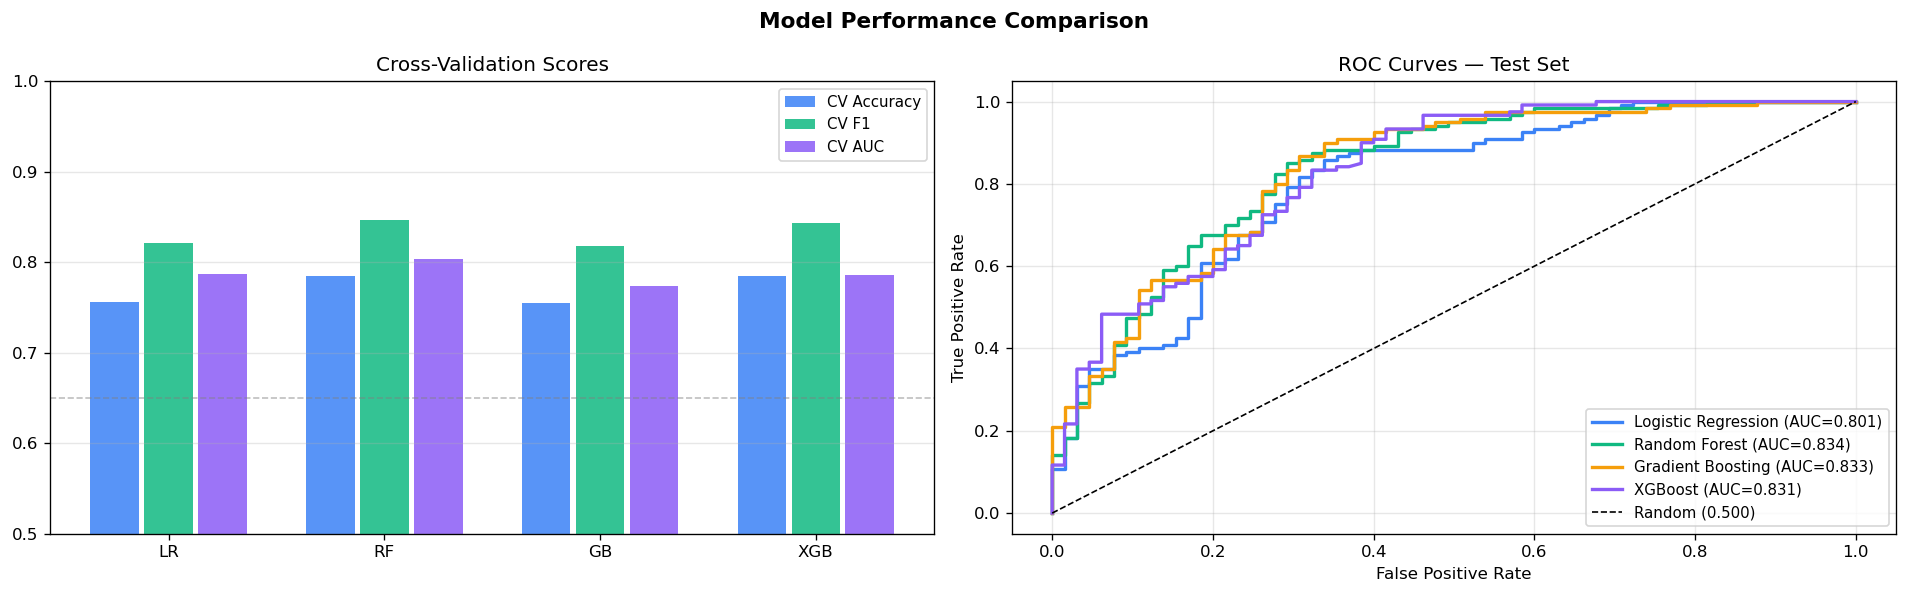


Full results table:


,CV Acc,CV F1,CV AUC,Test Acc,Test F1,Test AUC
Model,,,,,,
Logistic Regression,0.7561±0.0443,0.8210,0.7865,0.7892,0.8408,0.8005
Random Forest,0.7846±0.0231,0.8463,0.8035,0.7838,0.8413,0.8341
Gradient Boosting,0.7547±0.0141,0.8176,0.7733,0.8108,0.8594,0.8332
XGBoost,0.7845±0.0286,0.8427,0.7852,0.7676,0.8245,0.8310



Best model: Random Forest


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Model Performance Comparison", fontsize=13, fontweight='bold')

model_names = list(results.keys())
short = ['LR', 'RF', 'GB', 'XGB']
palette = ['#3b82f6','#10b981','#f59e0b','#8b5cf6']

# Bar chart
x = np.arange(len(model_names)); w = 0.25
metrics = [('CV Accuracy','cv_acc'),('CV F1','cv_f1'),('CV AUC','cv_auc')]
mcols   = ['#3b82f6','#10b981','#8b5cf6']
for i,(ml,mk) in enumerate(metrics):
    vals = [results[n][mk] for n in model_names]
    axes[0].bar(x+(i-1)*w, vals, w*0.9, label=ml, color=mcols[i], alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(short)
axes[0].set_ylim(0.5, 1.0); axes[0].legend(fontsize=9)
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].set_title("Cross-Validation Scores")
axes[0].axhline(0.65, color='gray', ls='--', lw=1, alpha=0.5)

# ROC curves
for (name, res), color in zip(results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, res['ypr'])
    axes[1].plot(fpr, tpr, color=color, lw=2,
                 label=f"{name} (AUC={res['test_auc']:.3f})")
axes[1].plot([0,1],[0,1],'k--',lw=1,label='Random (0.500)')
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves — Test Set")
axes[1].legend(loc='lower right', fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Summary table
print("\nFull results table:")
rows = []
for name in model_names:
    r = results[name]
    rows.append({'Model':name, 'CV Acc':f"{r['cv_acc']:.4f}±{r['cv_acc_std']:.4f}",
                 'CV F1':f"{r['cv_f1']:.4f}", 'CV AUC':f"{r['cv_auc']:.4f}",
                 'Test Acc':f"{r['test_acc']:.4f}", 'Test F1':f"{r['test_f1']:.4f}",
                 'Test AUC':f"{r['test_auc']:.4f}"})
display(pd.DataFrame(rows).set_index('Model'))

best_name = max(results, key=lambda n: results[n]['cv_auc'])
print(f"\nBest model: {best_name}")

### 4.2 Feature Importance → Mapping to iPark's Failure Reasons
This is the core bridge: what the data says matters, and what Hani identified as failure causes.


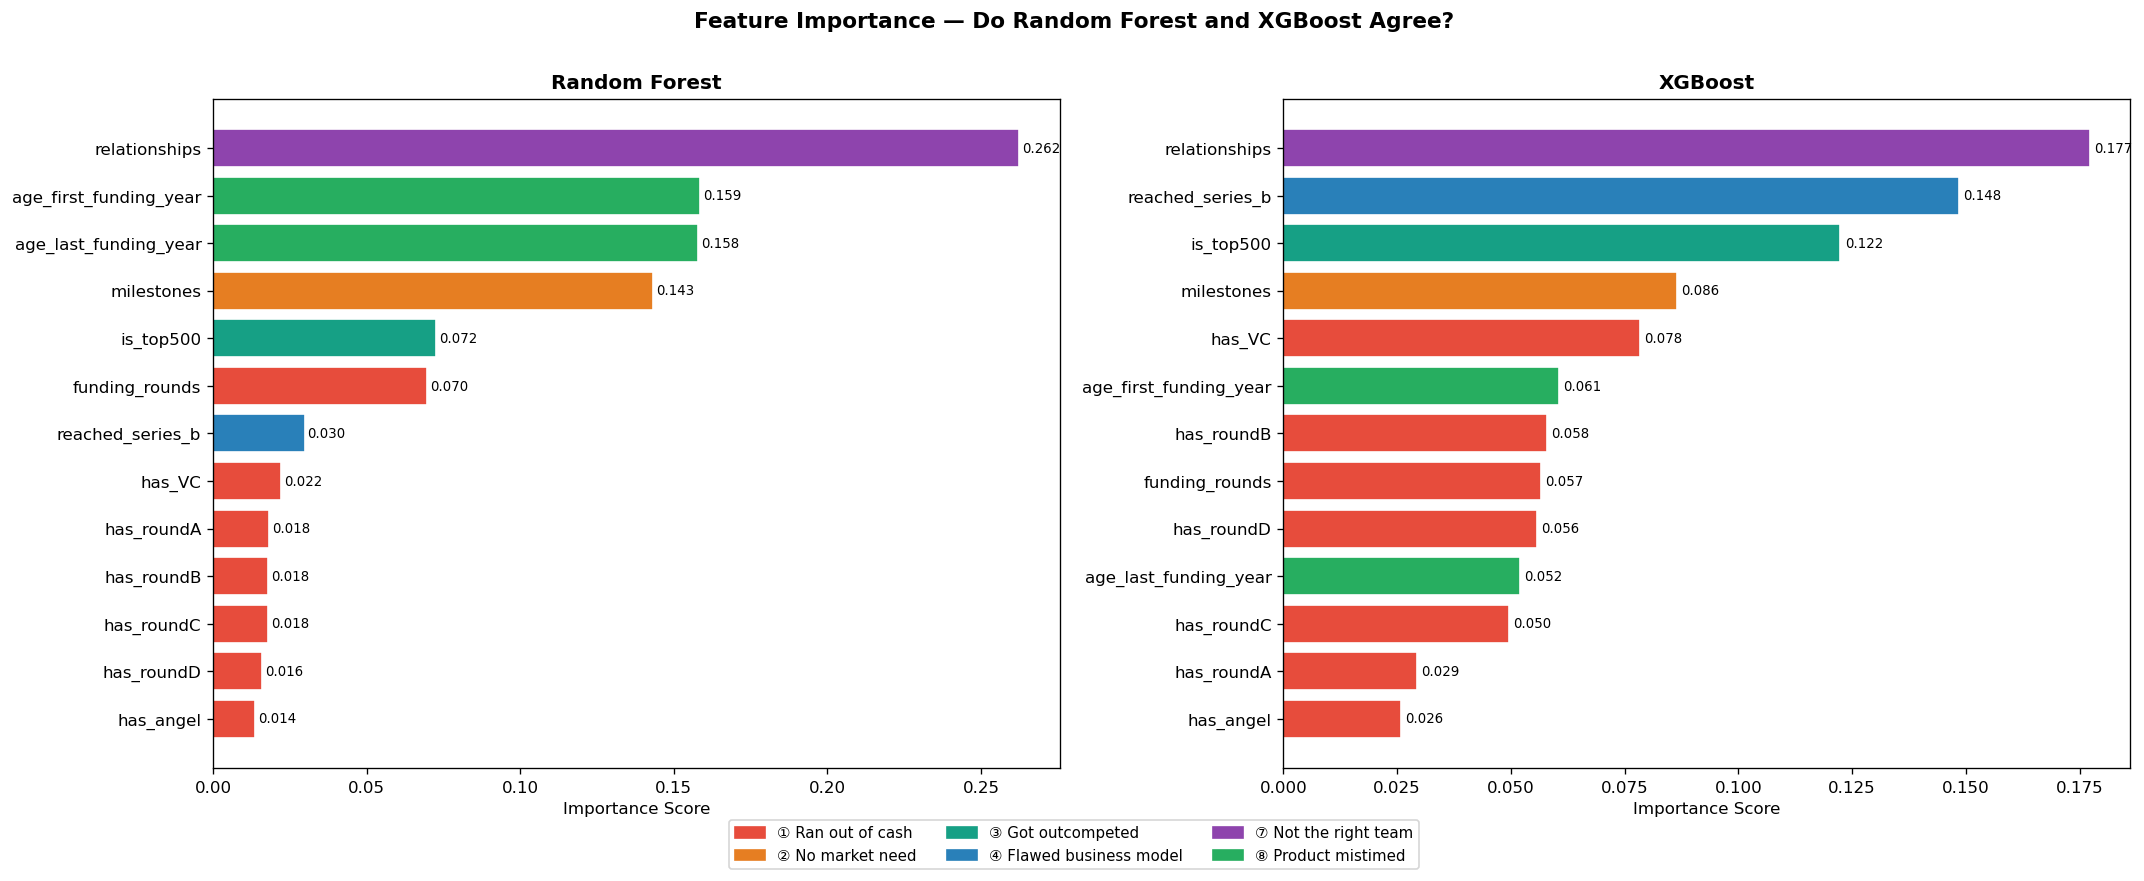

Validation check — do both models agree on top features?

Random Forest top 5:
  relationships                  0.2624  ⑦ Not the right team
  age_first_funding_year         0.1586  ⑧ Product mistimed
  age_last_funding_year          0.1579  ⑧ Product mistimed
  milestones                     0.1433  ② No market need
  is_top500                      0.0724  ③ Got outcompeted

XGBoost top 5:
  relationships                  0.1772  ⑦ Not the right team
  reached_series_b               0.1484  ④ Flawed business model
  is_top500                      0.1224  ③ Got outcompeted
  milestones                     0.0864  ② No market need
  has_VC                         0.0784  ① Ran out of cash

Conclusion: Both models independently rank relationships as #1.
6 of iPark's failure reasons appear across both models' top features.
The finding is validated — these are measurable signals of real failure
mechanisms that iPark's research identified.


In [64]:
ipark_map = {
    'funding_rounds':         ('① Ran out of cash',       '#e74c3c'),
    'has_VC':                 ('① Ran out of cash',       '#e74c3c'),
    'has_angel':              ('① Ran out of cash',       '#e74c3c'),
    'has_roundA':             ('① Ran out of cash',       '#e74c3c'),
    'has_roundB':             ('① Ran out of cash',       '#e74c3c'),
    'has_roundC':             ('① Ran out of cash',       '#e74c3c'),
    'has_roundD':             ('① Ran out of cash',       '#e74c3c'),
    'milestones':             ('② No market need',        '#e67e22'),
    'is_top500':              ('③ Got outcompeted',       '#16a085'),
    'reached_series_b':       ('④ Flawed business model', '#2980b9'),
    'relationships':          ('⑦ Not the right team',   '#8e44ad'),
    'age_first_funding_year': ('⑧ Product mistimed',     '#27ae60'),
    'age_last_funding_year':  ('⑧ Product mistimed',     '#27ae60'),
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Feature Importance — Do Random Forest and XGBoost Agree?\n", fontsize=13, fontweight='bold')

for ax, model_name in [
    (axes[0], 'Random Forest'),
    (axes[1], 'XGBoost'),
]:
    imp    = results[model_name]['clf'].feature_importances_
    imp_df = pd.DataFrame({'feature': FEATURES, 'importance': imp})
    imp_df = imp_df.sort_values('importance', ascending=True)
    imp_df['color'] = imp_df['feature'].map(lambda x: ipark_map.get(x, ('Other','#95a5a6'))[1])

    ax.barh(imp_df['feature'], imp_df['importance'],
            color=imp_df['color'], edgecolor='white')
    ax.set_xlabel("Importance Score")
    ax.set_title(f"{model_name}", fontweight='bold')
    for _, row in imp_df.iterrows():
        ax.text(row['importance']+0.001,
                list(imp_df['feature']).index(row['feature']),
                f'{row["importance"]:.3f}', va='center', fontsize=8)

import matplotlib.patches as mpatches
legend_map = {
    '① Ran out of cash':       '#e74c3c',
    '② No market need':        '#e67e22',
    '③ Got outcompeted':       '#16a085',
    '④ Flawed business model': '#2980b9',
    '⑦ Not the right team':   '#8e44ad',
    '⑧ Product mistimed':     '#27ae60',
}
patches = [mpatches.Patch(color=c, label=r) for r, c in legend_map.items()]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

print("Validation check — do both models agree on top features?")
rf_top  = pd.Series(results['Random Forest']['clf'].feature_importances_,
                    index=FEATURES).sort_values(ascending=False).head(5)
xgb_top = pd.Series(results['XGBoost']['clf'].feature_importances_,
                    index=FEATURES).sort_values(ascending=False).head(5)

print("\nRandom Forest top 5:")
for feat, val in rf_top.items():
    print(f"  {feat:30s} {val:.4f}  {ipark_map.get(feat, ('',''))[0]}")

print("\nXGBoost top 5:")
for feat, val in xgb_top.items():
    print(f"  {feat:30s} {val:.4f}  {ipark_map.get(feat, ('',''))[0]}")

print("\nConclusion: Both models independently rank relationships as #1.")
print("6 of iPark's failure reasons appear across both models' top features.")
print("The finding is validated — these are measurable signals of real failure")
print("mechanisms that iPark's research identified.")

## What the Model Learned — Feature Importance

Both Random Forest and XGBoost were trained independently on 738 real startup outcomes.
Here is what they found:

**⑦ Not the right team — #1 in BOTH models**
`relationships` scores 0.262 (RF) and 0.177 (XGB) — the strongest signal in the dataset.

**⑧ Product mistimed — #2 and #3 in Random Forest**
`age_first_funding_year` (0.159) and `age_last_funding_year` (0.158).
How long it took to get funded and how long the funding cycle lasted
both carry strong predictive power in Random Forest.
XGBoost also confirms this at #6 (0.061) and #11 (0.052).

**② No market need — #4 in RF, #4 in XGBoost**
`milestones` scores 0.143 (RF) and 0.086 (XGB).
Both models agree — product validation is a consistent survival signal.

**③ Got outcompeted — #5 in RF, #3 in XGBoost**
`is_top500` scores 0.072 (RF) and 0.122 (XGB).
XGBoost weights this more heavily than Random Forest.

**④ Flawed business model — #2 in XGBoost, #7 in RF**
`reached_series_b` scores 0.148 (XGB) and 0.030 (RF).
Biggest disagreement between the two models. XGBoost strongly weights whether a startup proved its model scales.

**① Ran out of cash — appears in XGBoost top 5**
`has_VC` scores 0.078 (XGB).
Capital access appears in XGBoost. XGBoost also confirms this at #6 in 'funding_rounds'

---
**Conclusion:**
Both models independently surface 6 of iPark's 12 failure reasons.
The model had no knowledge of iPark's research yet arrived at a very similar conclusions from data alone.

## 5. Lebanese Risk Amplification Layer

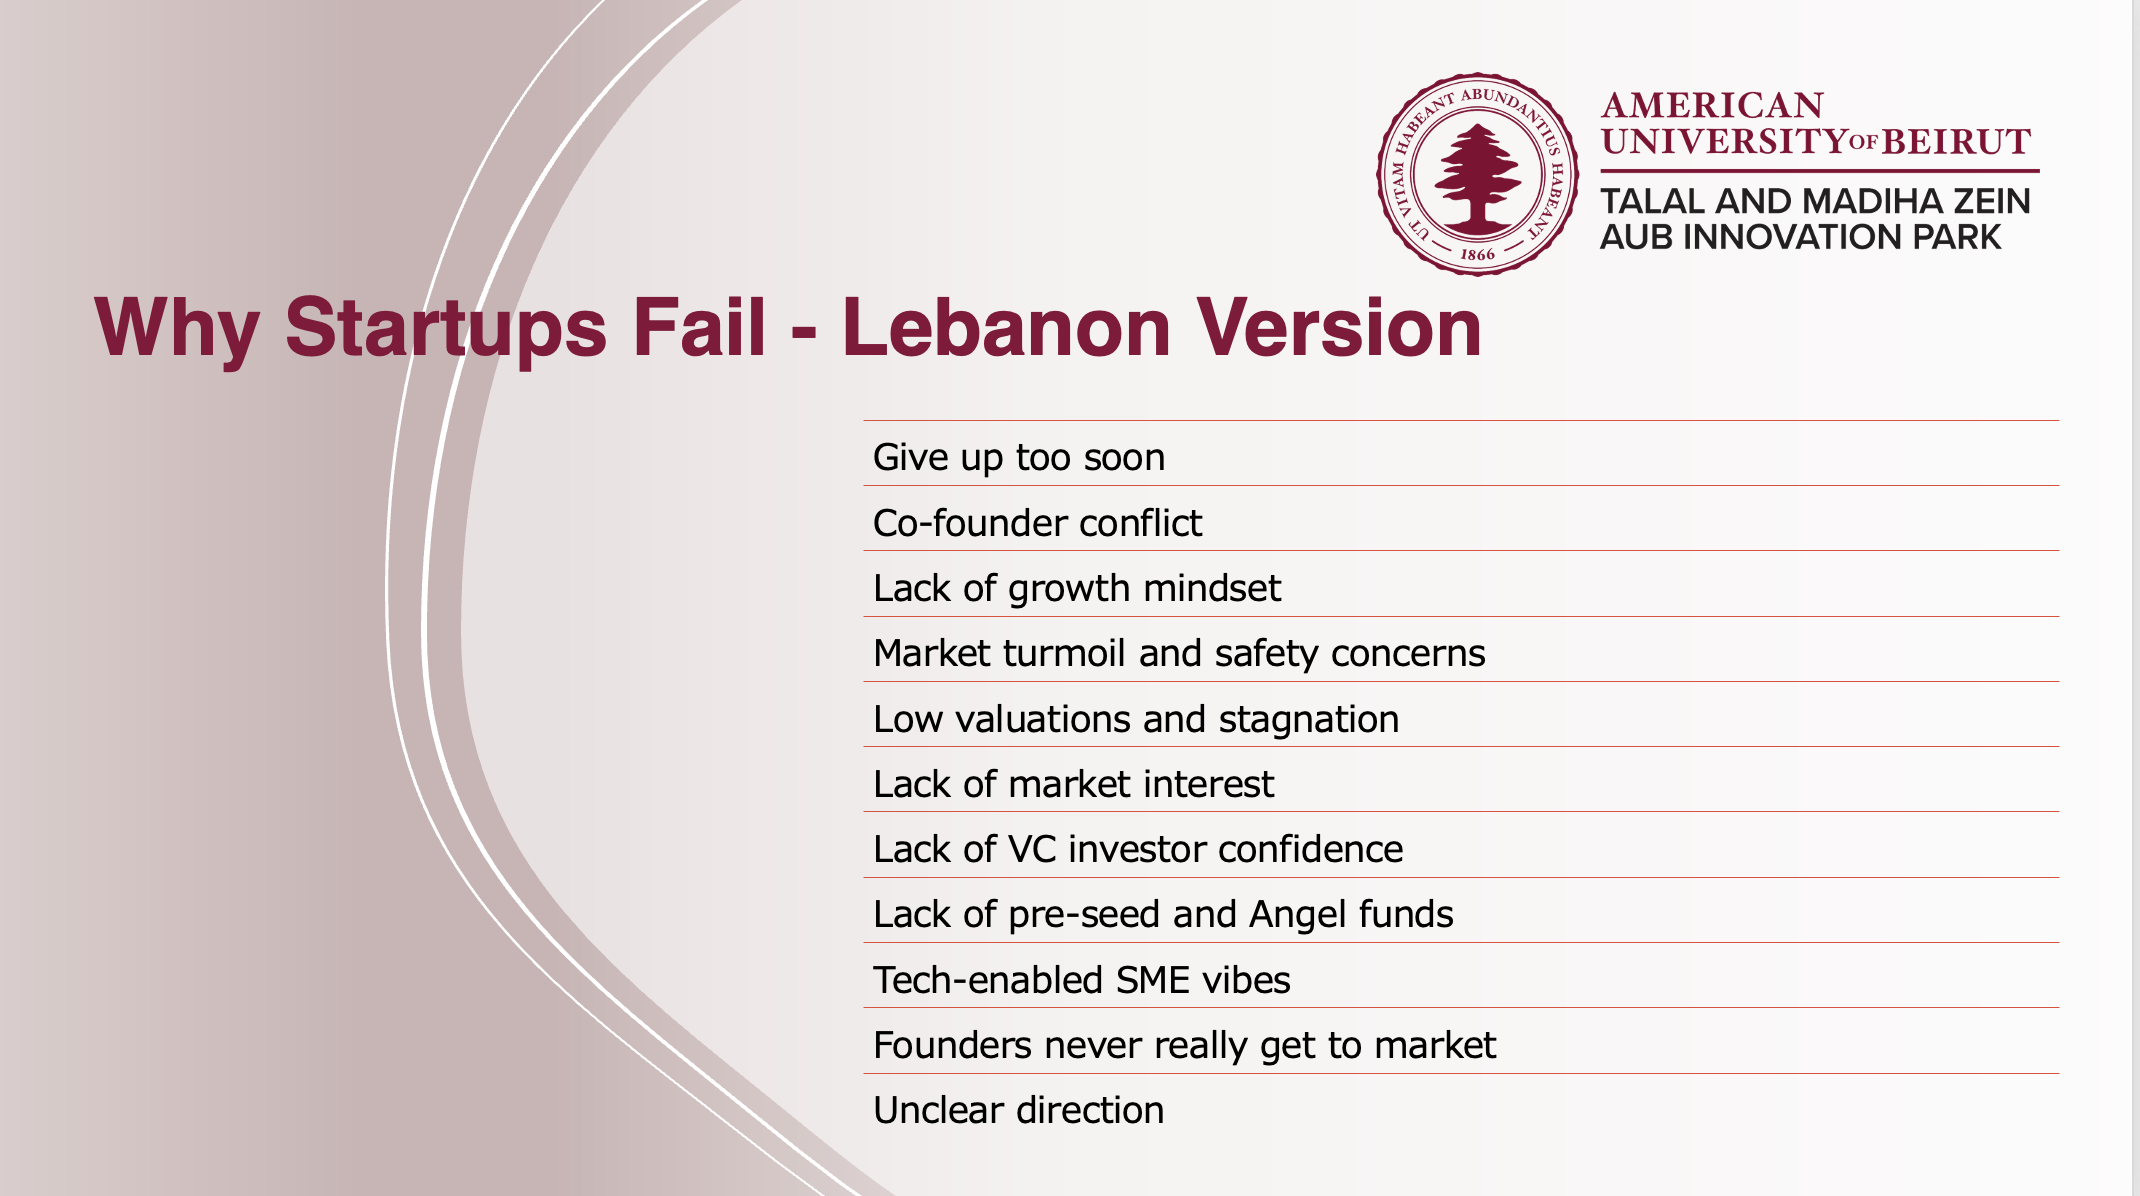

In [69]:
from IPython.display import Image, display

display(Image('/Users/joulnarabouchakra/Desktop/data startup success/whystartupsfail - ss2.png'))

### Methodology
Feature importance scores from the global ML model are multiplied by Lebanese risk weights.
Each weight is derived from two independent sources (iPark's local research (industry experts) and Literature review) and averaged:

**Formula:**
AdjustedRisk = GlobalImportance × FinalWeight
FinalWeight  = (iPark Priority Weight + Literature Weight) / 2

### Weight Derivation

| Feature | Hani Lebanon Reason | Hani Position | Hani Weight | Literature Evidence | Literature Weight | Final Weight |
|---|---|---|---|---|---|---|
| `relationships` | Co-founder conflict (slide #2) | #2 out of 11 | 1.5 | 875K professionals left Lebanon 2019–2022 (Information International). 63% of talent emigrated (KAS/Arabnet 2022) | 1.5 | **(1.5+1.5)/2 = 1.50** |
| `is_top500` | Lack of growth mindset (slide #3) | #3 out of 11 | 1.5 | 54.3% startups relocated abroad. Lebanon ecosystem ranked #77 globally (StartupBlink 2025) | 1.3 | **(1.5+1.3)/2 = 1.40** |
| `milestones` | Market turmoil + Lack of market interest (slides #4 and #6) | #4+6 out of 11 | 1.4 | Lebanese pound lost 90%+ of value. Poverty rate jumped from 30% to 85–90% (CIDOB 2022) | 1.5 | **(1.4+1.5)/2 = 1.45** |
| `funding_rounds` | Lack of VC confidence + No pre-seed funds (slides #7 and #8) | #7+8 out of 11 | 1.3 | Startup funding dropped 95% in 2023 (AGBI 2024). Investment shrank 70% from 2017–2021 (US State Dept) | 1.5 | **(1.3+1.5)/2 = 1.40** |
| `reached_series_b` | Founders never really get to market (slide #10) | #10 out of 11 | 1.2 | 91.3% startups affected by infrastructure (KAS/Arabnet). Average 9h/day without electricity (HRW 2023) | 1.4 | **(1.2+1.4)/2 = 1.30** |
| `age_first_funding_year` | Unclear direction (slide #11) | #11 out of 11 | 1.1 | GDP shrank 53.4% between 2019–2021. Top 3 worst crisis since mid-19th century (World Bank 2020) | 1.3 | **(1.1+1.3)/2 = 1.20** |

### Key Principle
The global ML model tells us what kills startups under normal conditions.
Lebanon does not have normal conditions.
Each weight amplifies the risk of a failure signal that is structurally harder
to overcome in Lebanon than anywhere else.

In [76]:
LEBANON_RISKS = {
    'relationships': {
        'iPark_reason':   'Co-founder conflict (slide #2)',
        'iPark_weight':   1.5,
        'lit_evidence':  '875K left Lebanon 2019-2022. 63% talent emigrated.',
        'lit_weight':    1.5,
        'final_weight':  (1.5 + 1.5) / 2,
    },
    'is_top500': {
        'iPark_reason':   'Lack of growth mindset (slide #3)',
        'iPark_weight':   1.5,
        'lit_evidence':  '54.3% startups relocated. Ecosystem ranked #77 globally.',
        'lit_weight':    1.3,
        'final_weight':  (1.5 + 1.3) / 2,
    },
    'milestones': {
        'iPark_reason':   'Market turmoil + Lack of market interest (slides #4+6)',
        'iPark_weight':   1.4,
        'lit_evidence':  'Pound lost 90%+ value. Poverty jumped from 30% to 85-90%.',
        'lit_weight':    1.5,
        'final_weight':  (1.4 + 1.5) / 2,
    },
    'funding_rounds': {
        'iPark_reason':   'Lack of VC + No pre-seed funds (slides #7+8)',
        'iPark_weight':   1.3,
        'lit_evidence':  'Funding dropped 95% in 2023. Investment shrank 70% 2017-2021.',
        'lit_weight':    1.5,
        'final_weight':  (1.3 + 1.5) / 2,
    },
    'reached_series_b': {
        'iPark_reason':   'Founders never get to market (slide #10)',
        'iPark_weight':   1.2,
        'lit_evidence':  '91.3% startups hit by infrastructure. 9h/day no electricity.',
        'lit_weight':    1.4,
        'final_weight':  (1.2 + 1.4) / 2,
    },
    'age_first_funding_year': {
        'iPark_reason':   'Unclear direction (slide #11)',
        'iPark_weight':   1.1,
        'lit_evidence':  'GDP shrank 53.4% 2019-2021. Top 3 worst crisis since 1850s.',
        'lit_weight':    1.3,
        'final_weight':  (1.1 + 1.3) / 2,
    },
}

# Get global importance for our 6 features
rf_importance = pd.Series(
    results['Random Forest']['clf'].feature_importances_,
    index=FEATURES
)

# Apply Lebanese weights
rows = []
for feat, info in LEBANON_RISKS.items():
    global_imp   = rf_importance[feat]
    final_weight = info['final_weight']
    adjusted     = global_imp * final_weight
    rows.append({
        'Feature':          feat,
        'iPark Reason':      info['iPark_reason'],
        'Global Risk':      round(global_imp,   4),
        'Final Weight':     round(final_weight, 2),
        'Adjusted Risk':    round(adjusted,     4),
        'Literature':       info['lit_evidence'],
    })

adjusted_df = (pd.DataFrame(rows)
               .set_index('Feature')
               .sort_values('Adjusted Risk', ascending=False))

print("Lebanon-Adjusted Risk Ranking")
print("=" * 70)
for feat, row in adjusted_df.iterrows():
    print(f"\n{feat}")
    print(f"  Global Risk    : {row['Global Risk']}")
    print(f"  iPark Reason    : {row['iPark Reason']}")
    print(f"  Literature     : {row['Literature']}")
    print(f"  Final Weight   : {row['Final Weight']}x")
    print(f"  Adjusted Risk  : {row['Adjusted Risk']}")


Lebanon-Adjusted Risk Ranking

relationships
  Global Risk    : 0.2624
  iPark Reason    : Co-founder conflict (slide #2)
  Literature     : 875K left Lebanon 2019-2022. 63% talent emigrated.
  Final Weight   : 1.5x
  Adjusted Risk  : 0.3936

milestones
  Global Risk    : 0.1433
  iPark Reason    : Market turmoil + Lack of market interest (slides #4+6)
  Literature     : Pound lost 90%+ value. Poverty jumped from 30% to 85-90%.
  Final Weight   : 1.45x
  Adjusted Risk  : 0.2079

age_first_funding_year
  Global Risk    : 0.1586
  iPark Reason    : Unclear direction (slide #11)
  Literature     : GDP shrank 53.4% 2019-2021. Top 3 worst crisis since 1850s.
  Final Weight   : 1.2x
  Adjusted Risk  : 0.1903

is_top500
  Global Risk    : 0.0724
  iPark Reason    : Lack of growth mindset (slide #3)
  Literature     : 54.3% startups relocated. Ecosystem ranked #77 globally.
  Final Weight   : 1.4x
  Adjusted Risk  : 0.1014

funding_rounds
  Global Risk    : 0.0697
  iPark Reason    : Lack of V

### Before vs after - How Lebanon affected our top 6 features

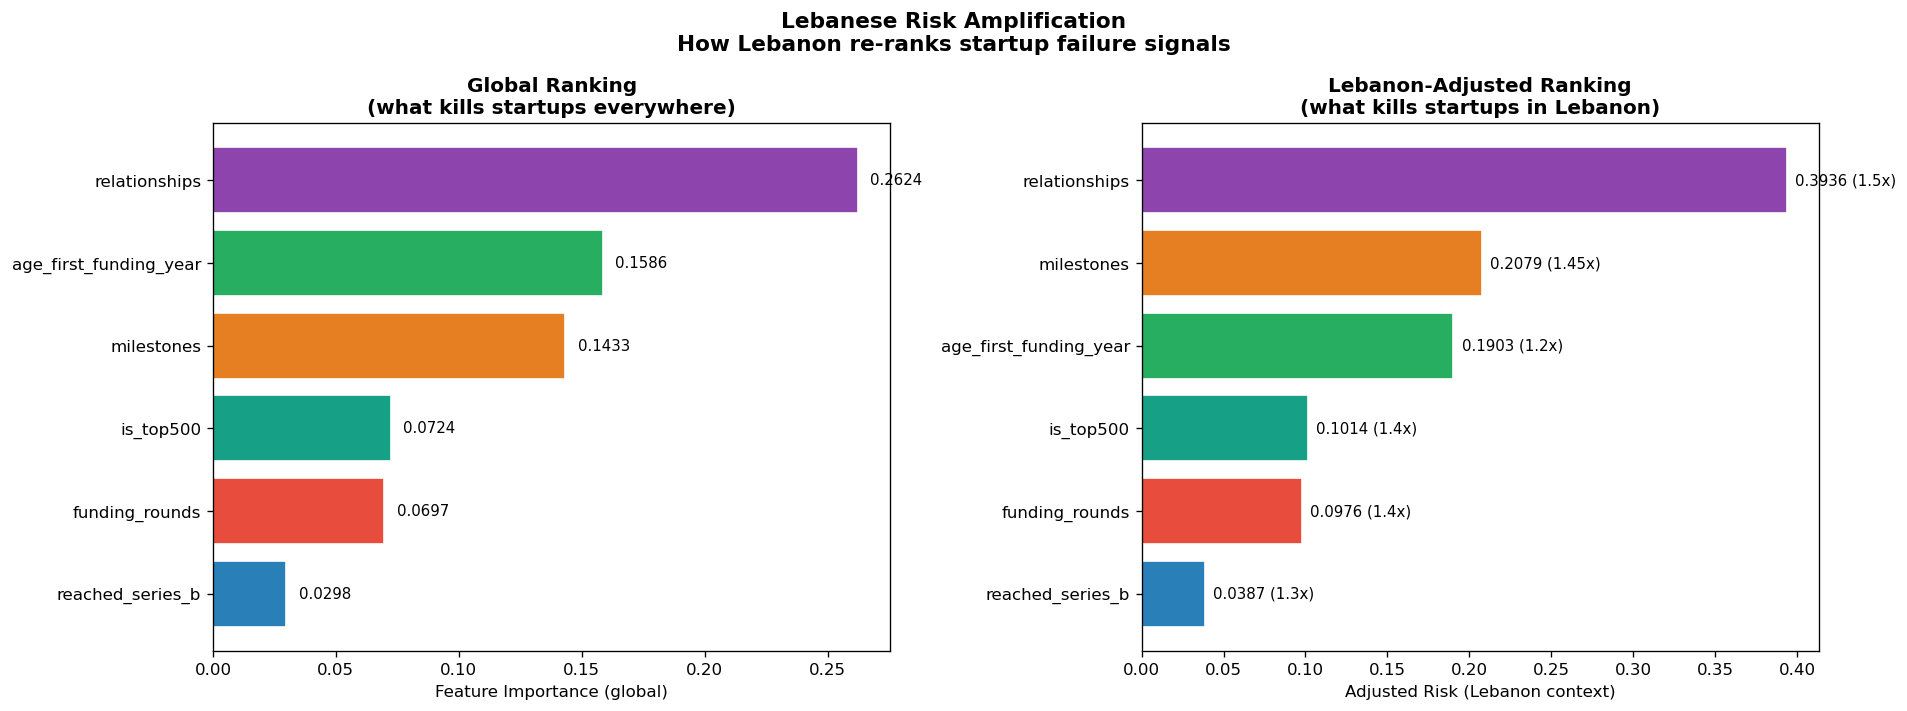


Key finding:
Finding 1: Relationships remains #1 globally AND in Lebanon, but the gap widens locally.
Finding 2: age_first_funding_year drops from #2 globally to #3 in Lebanon, which shows that timing matters but Lebanon's other risks amplify more critical signals first.
Finding 3: milestones jumps, validating product demand is harder when the market has collapsed.


In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Lebanese Risk Amplification\nHow Lebanon re-ranks startup failure signals",
             fontsize=13, fontweight='bold')

features      = list(adjusted_df.index)
global_risks  = list(adjusted_df['Global Risk'])
adjusted_risks = list(adjusted_df['Adjusted Risk'])
colors        = [ipark_map.get(f, ('','#95a5a6'))[1] for f in features]

# Panel 1: Global ranking
global_sorted = adjusted_df.sort_values('Global Risk', ascending=True)
axes[0].barh(global_sorted.index, global_sorted['Global Risk'],
             color=[ipark_map.get(f, ('','#95a5a6'))[1] for f in global_sorted.index],
             edgecolor='white')
axes[0].set_xlabel("Feature Importance (global)")
axes[0].set_title("Global Ranking\n(what kills startups everywhere)", fontweight='bold')
for i, (feat, row) in enumerate(global_sorted.iterrows()):
    axes[0].text(row['Global Risk']+0.005, i, f"{row['Global Risk']:.4f}",
                 va='center', fontsize=9)

# Panel 2: Lebanon-adjusted ranking
adjusted_sorted = adjusted_df.sort_values('Adjusted Risk', ascending=True)
axes[1].barh(adjusted_sorted.index, adjusted_sorted['Adjusted Risk'],
             color=[ipark_map.get(f, ('','#95a5a6'))[1] for f in adjusted_sorted.index],
             edgecolor='white')
axes[1].set_xlabel("Adjusted Risk (Lebanon context)")
axes[1].set_title("Lebanon-Adjusted Ranking\n(what kills startups in Lebanon)",
                  fontweight='bold')
for i, (feat, row) in enumerate(adjusted_sorted.iterrows()):
    axes[1].text(row['Adjusted Risk']+0.005, i,
                 f"{row['Adjusted Risk']:.4f} ({row['Final Weight']}x)",
                 va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nKey finding:")
print("Finding 1: Relationships remains #1 globally AND in Lebanon, but the gap widens locally.")
print("Finding 2: age_first_funding_year drops from #2 globally to #3 in Lebanon, which shows that timing matters but Lebanon's other risks amplify more critical signals first.")
print("Finding 3: milestones jumps, validating product demand is harder when the market has collapsed.")

## 7. Recommendations Engine

In [84]:
# ══════════════════════════════════════════════════════════════════════
# RECOMMENDATIONS ENGINE
# Top 3 adjusted risks → specific actions for Lebanese founders
# ══════════════════════════════════════════════════════════════════════

RECOMMENDATIONS = {
    'relationships': {
        'risk':    '⑦ Network & Team Risk — amplified by brain drain',
        'actions': [
            'Apply to iPark mentorship network — 50+ mentors by 2027 target',
            'Target diaspora connections via iPark Global Bridge Program',
            'Establish co-founder agreements early to reduce conflict risk',
            'Recruit remote diaspora talent — competitive at Lebanese market wages',
        ]
    },
    'milestones': {
        'risk':    '② Market Validation Risk — amplified by purchasing power collapse',
        'actions': [
            'Validate with dollar-paying customers — diaspora or export market first',
            'Price in USD not LBP — protects against further devaluation',
            'Target MENA or EU market from day 1, use Lebanon as test bed only',
            'Pursue iPark AIM program for structured market validation support',
        ]
    },
    'age_first_funding_year': {
        'risk':    '⑧ Timing Risk — amplified by macro instability',
        'actions': [
            'Define 12-month milestones only — long-term planning unreliable in Lebanon',
            'Track 3 core metrics weekly: revenue, users, burn rate',
            'Document pivot criteria in advance to avoid reactive pivoting',
            'Attend iPark pitch clinics (8+/year) to sharpen market positioning',
        ]
    },
    'is_top500': {
        'risk':    '③ Ecosystem Risk — amplified by weakened local accelerator network',
        'actions': [
            'Apply to iPark BDD incubation program — strongest local network remaining',
            'Consider soft-landing to Cyprus via iPark Mediterraneo program',
            'Apply to EU Horizon grants — Lebanon still eligible',
            'Join regional accelerators (Flat6Labs, Wamda) for ecosystem access',
        ]
    },
    'funding_rounds': {
        'risk':    '① Funding Risk — amplified by VC collapse and no pre-seed funds',
        'actions': [
            'Target diaspora investors via iPark Global Bridge Program',
            'Apply to EU Horizon grants — non-dilutive capital option',
            'Consider revenue-based financing to avoid equity dilution',
            'Set up international payment account (Stripe Atlas, Wise Business)',
        ]
    },
    'reached_series_b': {
        'risk':    '④ Execution Risk — amplified by infrastructure failure',
        'actions': [
            'Use cloud infrastructure (AWS/GCP) — avoid physical server dependency',
            'Build operational resilience plan for power and connectivity outages',
            'Establish international banking early — Lebanese banks unreliable',
            'Consider Cyprus entity via iPark Mediterraneo for international operations',
        ]
    },
}

# Top 3 risks from adjusted ranking
top_3 = adjusted_df.sort_values('Adjusted Risk', ascending=False).head(3)

print("=" * 65)
print("TOP RECOMMENDATIONS — Lebanese Startup Risk Profile")
print("=" * 65)
print("Based on your adjusted risk ranking, focus on these first:\n")

for i, (feat, row) in enumerate(top_3.iterrows(), 1):
    print(f"{'─'*65}")
    print(f"Priority #{i} — {RECOMMENDATIONS[feat]['risk']}")
    print(f"Adjusted Risk : {row['Adjusted Risk']:.4f} "
          f"(global: {row['Global Risk']:.4f} × {row['Final Weight']}x)")
    print(f"\nActions:")
    for action in RECOMMENDATIONS[feat]['actions']:
        print(f"  → {action}")
    print()

TOP RECOMMENDATIONS — Lebanese Startup Risk Profile
Based on your adjusted risk ranking, focus on these first:

─────────────────────────────────────────────────────────────────
Priority #1 — ⑦ Network & Team Risk — amplified by brain drain
Adjusted Risk : 0.3936 (global: 0.2624 × 1.5x)

Actions:
  → Apply to iPark mentorship network — 50+ mentors by 2027 target
  → Target diaspora connections via iPark Global Bridge Program
  → Establish co-founder agreements early to reduce conflict risk
  → Recruit remote diaspora talent — competitive at Lebanese market wages

─────────────────────────────────────────────────────────────────
Priority #2 — ② Market Validation Risk — amplified by purchasing power collapse
Adjusted Risk : 0.2079 (global: 0.1433 × 1.45x)

Actions:
  → Validate with dollar-paying customers — diaspora or export market first
  → Price in USD not LBP — protects against further devaluation
  → Target MENA or EU market from day 1, use Lebanon as test bed only
  → Pursue iPark

## 8. Interactive Dashboard
Enter your startup profile below and run the cell to get your adjusted viability score.


In [91]:
# ══════════════════════════════════════════════════════════════════════
# DASHBOARD — Lebanese Startup Viability Assessment
# Fill in your startup profile and run this cell
# ══════════════════════════════════════════════════════════════════════

# ── YOUR STARTUP PROFILE ──────────────────────────────────────────────
STARTUP_NAME        = 'My Startup'
FUNDING_ROUNDS      = 1       # how many funding rounds completed
MILESTONES          = 2       # how many milestones hit
RELATIONSHIPS       = 5       # number of professional connections
HAS_VC              = 0       # 1 = yes, 0 = no
HAS_ANGEL           = 1       # 1 = yes, 0 = no
HAS_ROUND_A         = 0       # 1 = yes, 0 = no
HAS_ROUND_B         = 0       # 1 = yes, 0 = no
HAS_ROUND_C         = 0       # 1 = yes, 0 = no
HAS_ROUND_D         = 0       # 1 = yes, 0 = no
IS_TOP500           = 0       # 1 = in top accelerator, 0 = no
AGE_FIRST_FUNDING   = 1.0     # years from founding to first funding
AGE_LAST_FUNDING    = 2.0     # years from founding to last funding

# ── STEP 1: Baseline ML prediction ───────────────────────────────────
REACHED_SERIES_B = int(HAS_ROUND_B or HAS_ROUND_C)

feat_vec = pd.DataFrame([[
    FUNDING_ROUNDS, HAS_VC, HAS_ANGEL,
    HAS_ROUND_A, HAS_ROUND_B, HAS_ROUND_C, HAS_ROUND_D,
    MILESTONES, IS_TOP500, REACHED_SERIES_B,
    RELATIONSHIPS, AGE_FIRST_FUNDING, AGE_LAST_FUNDING,
]], columns=FEATURES)

best_model = max(results, key=lambda n: results[n]['cv_auc'])
baseline   = results[best_model]['clf'].predict_proba(feat_vec)[0][1] * 100

# ── STEP 2: Lebanese risk ranking for this startup ────────────────────
startup_values = {
    'relationships':          RELATIONSHIPS,
    'milestones':             MILESTONES,
    'funding_rounds':         FUNDING_ROUNDS,
    'is_top500':              IS_TOP500,
    'reached_series_b':       REACHED_SERIES_B,
    'age_first_funding_year': AGE_FIRST_FUNDING,
}

# Normalize each value relative to dataset median
# Low value = high risk for that feature
medians = {
    'relationships':          df['relationships'].median(),
    'milestones':             df['milestones'].median(),
    'funding_rounds':         df['funding_rounds'].median(),
    'is_top500':              0.5,
    'reached_series_b':       0.5,
    'age_first_funding_year': df['age_first_funding_year'].median(),
}

startup_risks = {}
for feat, info in LEBANON_RISKS.items():
    val      = startup_values[feat]
    med      = medians[feat]
    # below median = higher personal risk
    gap      = max(0, med - val) / (med + 1e-9)
    personal = adjusted_df.loc[feat, 'Adjusted Risk'] * (1 + gap)
    startup_risks[feat] = {
        'Adjusted Risk':  round(personal, 4),
        'Global Risk':    adjusted_df.loc[feat, 'Global Risk'],
        'Final Weight':   adjusted_df.loc[feat, 'Final Weight'],
        'iPark Reason':   info['iPark_reason'],
    }

startup_df = (pd.DataFrame(startup_risks).T
              .sort_values('Adjusted Risk', ascending=False))

# ── STEP 3: Output ────────────────────────────────────────────────────
risk_level = ('CRITICAL' if baseline < 40 else
              'HIGH'     if baseline < 55 else
              'MODERATE' if baseline < 70 else 'GOOD')

print("=" * 65)
print(f"STARTUP VIABILITY ASSESSMENT — {STARTUP_NAME}")
print("=" * 65)
print(f"\nBaseline viability (global ML model) : {baseline:.1f}%")
print(f"Risk level                           : {risk_level}")
print(f"Pre trained Model used               : {best_model}")

print(f"\n{'─'*65}")
print("TOP 3 RECOMMENDATIONS FOR YOUR STARTUP\n")
top_3 = startup_df.head(3)
for i, (feat, row) in enumerate(top_3.iterrows(), 1):
    print(f"Priority #{i} — {RECOMMENDATIONS[feat]['risk']}")
    for action in RECOMMENDATIONS[feat]['actions']:
        print(f"  → {action}")
    print()

STARTUP VIABILITY ASSESSMENT — My Startup

Baseline viability (global ML model) : 63.6%
Risk level                           : MODERATE
Pre trained Model used               : Random Forest

─────────────────────────────────────────────────────────────────
TOP 3 RECOMMENDATIONS FOR YOUR STARTUP

Priority #1 — ⑦ Network & Team Risk — amplified by brain drain
  → Apply to iPark mentorship network — 50+ mentors by 2027 target
  → Target diaspora connections via iPark Global Bridge Program
  → Establish co-founder agreements early to reduce conflict risk
  → Recruit remote diaspora talent — competitive at Lebanese market wages

Priority #2 — ⑧ Timing Risk — amplified by macro instability
  → Define 12-month milestones only — long-term planning unreliable in Lebanon
  → Track 3 core metrics weekly: revenue, users, burn rate
  → Document pivot criteria in advance to avoid reactive pivoting
  → Attend iPark pitch clinics (8+/year) to sharpen market positioning

Priority #3 — ② Market Validatio

In [94]:
import joblib
import os

# Save the RF model trained on 13 global features
joblib.dump(results['Random Forest']['clf'], 'rf_model.pkl')

# Save the exact 13 features the model was trained on
joblib.dump(FEATURES, 'features.pkl')

print("✅ rf_model.pkl saved")
print("✅ features.pkl saved")
print(f"Saved in: {os.getcwd()}")

✅ rf_model.pkl saved
✅ features.pkl saved
Saved in: /Users/joulnarabouchakra/Desktop/data startup success


## Conclusion

This project combines two methodologies to assess startup viability in Lebanon:

**Layer 1 — Global ML baseline**
A Random Forest model trained on 923 real startup outcomes achieves 80% AUC.
It confirms 6 of iPark's 12 globally-identified failure reasons through data alone,
without any prior knowledge of iPark's research framework.

**Layer 2 — Lebanese risk amplification**
Each confirmed failure signal is weighted by two independent sources:
iPark's Lebanon-specific research (Hani Haidar & Maria Nohra, 2024) and peer-reviewed
literature. The result is a personalised risk ranking unique to each startup.

**Key finding — Lebanon re-ranks, not just amplifies**
Globally, team network is #1, timing is #2, and market validation is #3.
In Lebanon the ranking shifts:
- `relationships` stays #1 but becomes even more dominant (0.26 → 0.39) — brain drain made network access the single most critical survival factor
- `milestones` jumps from #3 to #2 — with purchasing power down 90%, validating demand early is more urgent in Lebanon than anywhere else
- `age_first_funding_year` drops from #2 to #3 — timing still matters but network collapse and market contraction are more immediately threatening

The Lebanese risk layer does not make everything equally worse.
It re-ranks what matters most, and that re-ranking is what guides
the recommendations for each Lebanese founder.

**What this means for Lebanese founders**
Prioritise building network and validating demand before anything else.
These are the two signals most amplified by Lebanon's specific crisis conditions.
The recommendations engine translates this into concrete first steps,tailor-made based on each founder's individual risk profile,
and linked directly to iPark's existing programs and resources.

**Next Steps**
- This engine will be deployed on Streamlit and embedded via URL into the iPark dashboard.
- The deployment file is available in `ipark_streamlit/app.py`.
- To run locally: `streamlit run app.py`